In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import xarray as xr

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [39]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
from taylor_setup import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# %% 10. Load-only cell: usable in a fresh kernel without rerunning the calculations
# Only load pickle-containing .npy dictionaries that you created/trust.
import numpy as np
from pathlib import Path

overlap_save_dir        = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
overlap_member_values   = np.load(overlap_save_dir / "overlap_member_values.npy", allow_pickle=True).item()
overlap_model_means     = np.load(overlap_save_dir / "overlap_model_means.npy", allow_pickle=True).item()
overlap_MMM             = np.load(overlap_save_dir / "overlap_MMM.npy", allow_pickle=True).item()
overlap_observations    = np.load(overlap_save_dir / "overlap_observations.npy", allow_pickle=True).item()
overlap_model_n_valid   = np.load(overlap_save_dir / "overlap_model_n_valid.npy", allow_pickle=True).item()
overlap_MMM_n_valid     = np.load(overlap_save_dir / "overlap_MMM_n_valid.npy", allow_pickle=True).item()
overlap_model_names     = np.load(overlap_save_dir / "overlap_model_names.npy", allow_pickle=True).item()
overlap_member_ids      = np.load(overlap_save_dir / "overlap_member_ids.npy", allow_pickle=True).item()
overlap_coordinates     = np.load(overlap_save_dir / "overlap_coordinates.npy", allow_pickle=True).item()
overlap_quantity_info   = np.load(overlap_save_dir / "overlap_quantity_info.npy", allow_pickle=True).item()
overlap_sources         = np.load(overlap_save_dir / "overlap_sources.npy", allow_pickle=True).item()
overlap_metadata        = np.load(overlap_save_dir / "overlap_metadata.npy", allow_pickle=True).item()

In [33]:
overlap_model_names

{'amip_hist': ['BCC-CSM2-MR',
  'CAMS-CSM1-0',
  'CESM2',
  'CIESM',
  'CNRM-CM6-1',
  'CNRM-CM6-1-HR',
  'CNRM-ESM2-1',
  'CanESM5',
  'FGOALS-f3-L',
  'FGOALS-g3',
  'FIO-ESM-2-0',
  'IITM-ESM',
  'IPSL-CM6A-LR',
  'MIROC6',
  'MRI-ESM2-0',
  'TaiESM1'],
 'historical': ['ACCESS-CM2',
  'ACCESS-ESM1-5',
  'AWI-CM-1-1-MR',
  'AWI-ESM-1-1-LR',
  'BCC-CSM2-MR',
  'BCC-ESM1',
  'CAMS-CSM1-0',
  'CAS-ESM2-0',
  'CESM2',
  'CESM2-FV2',
  'CESM2-WACCM',
  'CESM2-WACCM-FV2',
  'CIESM',
  'CMCC-CM2-HR4',
  'CMCC-CM2-SR5',
  'CMCC-ESM2',
  'CNRM-CM6-1',
  'CNRM-CM6-1-HR',
  'CNRM-ESM2-1',
  'CanESM5',
  'CanESM5-CanOE',
  'E3SM-1-0',
  'E3SM-1-1',
  'E3SM-1-1-ECA',
  'EC-Earth3',
  'EC-Earth3-AerChem',
  'EC-Earth3-Veg',
  'EC-Earth3-Veg-LR',
  'FGOALS-f3-L',
  'FGOALS-g3',
  'FIO-ESM-2-0',
  'GISS-E2-1-G',
  'GISS-E2-1-G-CC',
  'GISS-E2-1-H',
  'IITM-ESM',
  'INM-CM4-8',
  'INM-CM5-0',
  'IPSL-CM5A2-INCA',
  'IPSL-CM6A-LR',
  'IPSL-CM6A-LR-INCA',
  'KACE-1-0-G',
  'KIOST-ESM',
  'MIROC6',
  'M

In [4]:
# %% 6. Load-only cell: works in a fresh kernel, without raw fields or scoring functions
# These .npy dictionaries contain pickle data; load only files you created/trust.
import numpy as np
from pathlib import Path

overlap_score_save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs")
# The first three containers use [experiment][quantity][model][score].
overlap_member_scores = np.load(overlap_score_save_dir / "overlap_member_scores.npy", allow_pickle=True).item()
overlap_mean_member_scores = np.load(overlap_score_save_dir / "overlap_mean_member_scores.npy", allow_pickle=True).item()
overlap_model_mean_scores = np.load(overlap_score_save_dir / "overlap_model_mean_scores.npy", allow_pickle=True).item()
# The two MMM containers use [experiment][quantity][score], without a model key.
overlap_MMM_scores = np.load(overlap_score_save_dir / "overlap_MMM_scores.npy", allow_pickle=True).item()
overlap_MMM_mean_member_scores = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_scores.npy", allow_pickle=True).item()

overlap_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_MMM_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_score_model_names = np.load(overlap_score_save_dir / "overlap_score_model_names.npy", allow_pickle=True).item()
overlap_score_member_ids = np.load(overlap_score_save_dir / "overlap_score_member_ids.npy", allow_pickle=True).item()
overlap_score_metadata = np.load(overlap_score_save_dir / "overlap_score_metadata.npy", allow_pickle=True).item()


In [10]:
print(overlap_member_scores['amip_hist']['sigma_T']['CESM2'])

{'value_x': array([0.11364338, 0.11364338, 0.11364338]), 'value_y': array([0.13533236, 0.12899872, 0.13364351]), 'bias': array([0.02168898, 0.01535534, 0.02000013]), 'rmse': array([0.02168898, 0.01535534, 0.02000013]), 'value_ratio': array([1.19085122, 1.13511865, 1.17599026]), 'rmse_over_rms_x': array([0.19085122, 0.13511865, 0.17599026]), 'bias_over_rms_x': array([0.19085122, 0.13511865, 0.17599026]), 'n_valid': array([1, 1, 1]), 'valid_weight_fraction': array([1., 1., 1.])}


In [7]:
print(overlap_score_metadata['score_keys']['corr_Ti_Ri'])
print(overlap_score_metadata['score_keys']['sigma_T'])

['rmse', 'bias', 'centered_rmse', 'pattern_correlation', 'contrast_ratio', 'norm_ratio', 'cosine', 'lin_ccc', 'rmse_over_rms_x', 'bias_over_rms_x', 'rmse_over_std_x', 'bias_over_std_x', 'centered_rmse_over_std_x', 'mean_x', 'mean_y', 'std_x', 'std_y', 'rms_x', 'rms_y', 'n_valid', 'valid_weight_fraction']
['value_x', 'value_y', 'bias', 'rmse', 'value_ratio', 'rmse_over_rms_x', 'bias_over_rms_x', 'n_valid', 'valid_weight_fraction']


In [16]:
# List out quantities in the data structure
for key, list_obj in overlap_quantity_info.items():
    print(f"--- {key} ---")
    # print(*list_obj, sep='\n')
    # print(list_obj)

--- corr_Ti_Ri ---
--- corr_T_Ri ---
--- corr_Ti_R ---
--- corr_T_R ---
--- sigma_Ti ---
--- sigma_Ri ---
--- sigma_T ---
--- sigma_R ---
--- T_detrended ---
--- R_detrended ---
--- T_trend_in ---
--- R_trend_in ---
--- cov_Zi_R ---
--- cov_Ti_R ---
--- cov_T_Qi ---
--- cov_T_Ri ---
--- cov_Zi_Ri ---
--- cov_Ti_Qi ---
--- cov_Ti_Ri ---


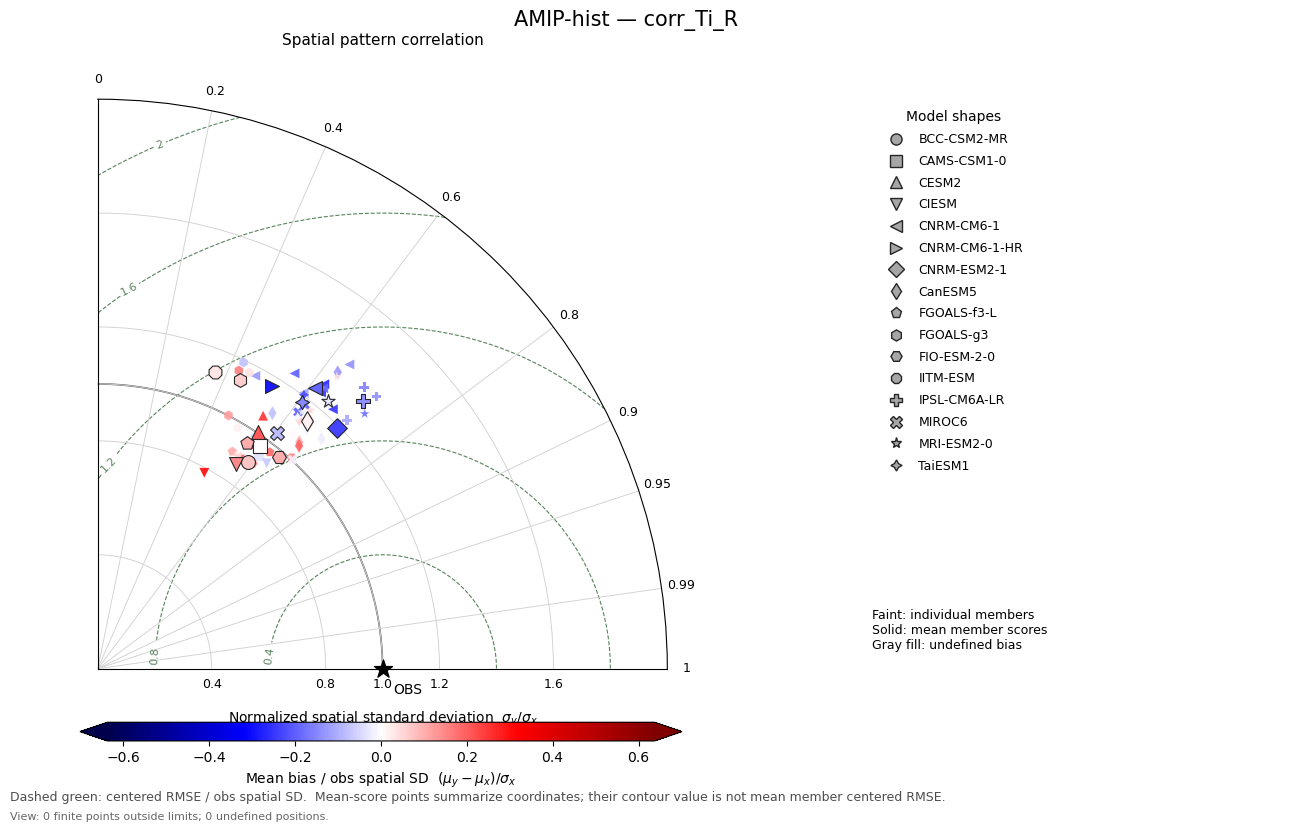

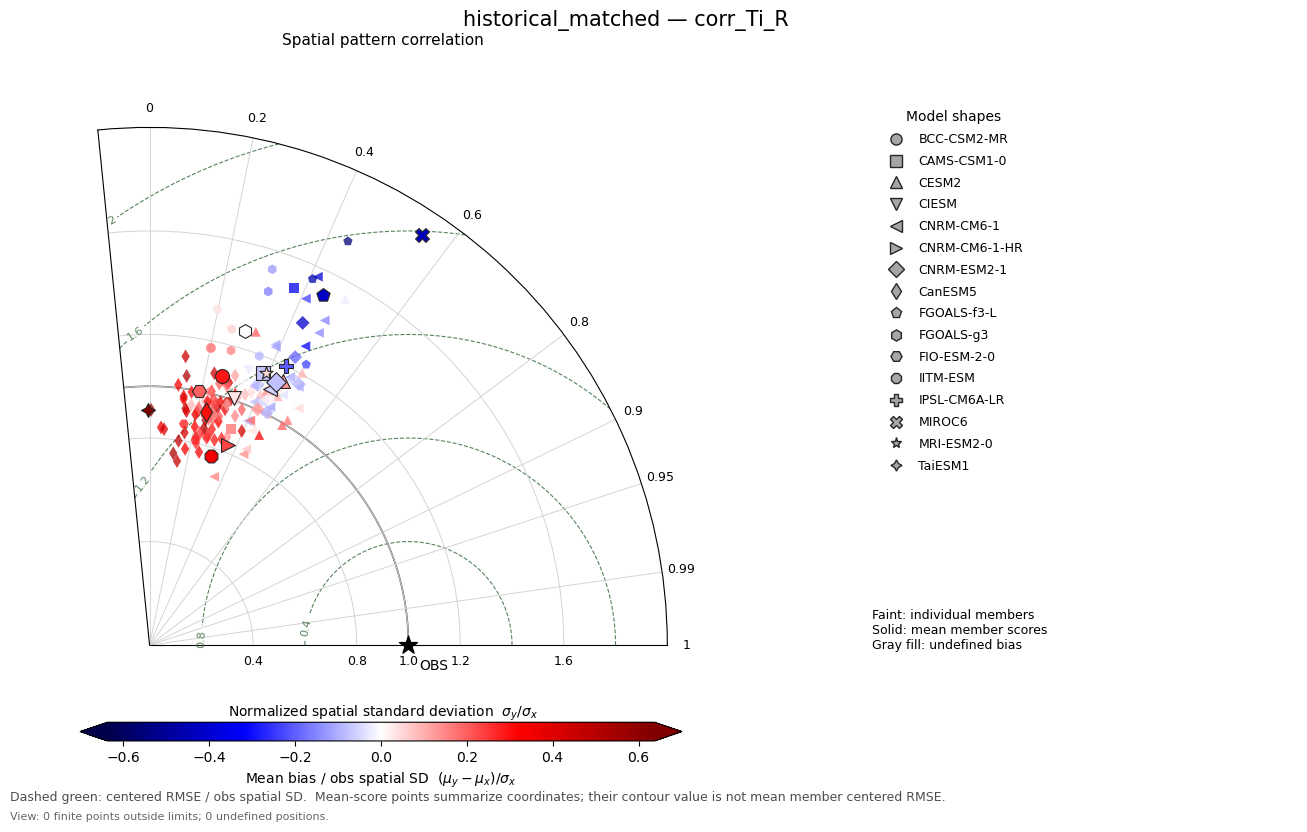

In [25]:
# Set up and run taylor diagram with existing prep functions
taylor_metric = "corr_Ti_R" # Equivalent to cov_Zi_Q     

taylor_bias_key = "bias_over_std_x"        # Dimensionless signed bias, matching Taylor normalization.
taylor_bias_label = r"Mean bias / obs spatial SD  $(\mu_y-\mu_x)/\sigma_x$"        

taylor_members, taylor_means = prepare_taylor_tables(
    overlap_member_scores, overlap_mean_member_scores,  # These should be the data structures scoring lives in 
    taylor_metric, bias_key=taylor_bias_key             # Options for the bias (so what marker color/size represents)
)

# IMPORTANT: this sigma_x is the spatial SD of the OBS DIAGNOSTIC MAP, not the
# temporal temperature SD used when constructing regTiRi/covRTi in the first place.
# All input scores should use the same spatial domain/weights. Pairwise masks
# cannot be reconciled by plotting; use a common mask upstream when needed.
amip_names = list(overlap_member_scores["amip_hist"][taylor_metric])
matched_names = list(overlap_member_scores["historical_matched"][taylor_metric])
if set(amip_names) != set(matched_names):
    raise ValueError("Expected the same model set for AMIP and historical_matched.")
taylor_markers = {model: TAYLOR_SHAPES[i] for i, model in enumerate(amip_names[:16])}

# If a different <=16-model group contains additional names, give it its own
# available shapes while preserving assignments for models already in AMIP.
for experiment in ["historical_matched", "historical"]:
    names = list(overlap_member_scores[experiment][taylor_metric])
    if len(names) <= 16:
        used = {repr(taylor_markers[name]) for name in names if name in taylor_markers}
        remaining = [shape for shape in TAYLOR_SHAPES if repr(shape) not in used]
        for name in names:
            if name not in taylor_markers:
                taylor_markers[name] = remaining.pop(0)

# Use the SAME bias color scale in AMIP, matched historical, and the arrow plot.
# Default: include all finite member and mean biases in the two matched groups.
# Set taylor_bias_vlim manually if wanted; colorbar extensions mark saturation.
matched_bias = pd.concat([
    taylor_members.loc[taylor_members["experiment"].isin(["amip_hist", "historical_matched"]), "bias"],
    taylor_means.loc[taylor_means["experiment"].isin(["amip_hist", "historical_matched"]), "bias"]
]).to_numpy()
finite_bias = np.abs(matched_bias[np.isfinite(matched_bias)])
taylor_bias_vlim = float(finite_bias.max()) if finite_bias.size and finite_bias.max() > 0 else 1.0
# taylor_bias_vlim = 2.0

# Equal rmax/corr_min values across calls make separate diagrams directly
# comparable visually. None uses full-data bounds for each figure independently.
# zoom=True trims unused angular space. Manual rmax/corr_min may exclude points,
# but never changes the averages, and the figure reports exclusions.



fig_taylor_QZi, ax_taylor_QZi, key_taylor_QZi = plot_taylor_experiment(
    taylor_members, taylor_means, 
    "amip_hist", ######
    taylor_markers,
    title=f"AMIP-hist — {taylor_metric}", #######
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    rmax=2, corr_min=None, zoom=False, #######
    member_alpha=0.9, member_size=50, mean_size=100, cmap="seismic", #######
)
# fig_taylor_QZi.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_amip_regTiRi.png", dpi=300, bbox_inches="tight")
plt.show()

fig_taylor_QZi, ax_taylor_QZi, key_taylor_QZi = plot_taylor_experiment(
    taylor_members, taylor_means, 
    "historical_matched", ######
    taylor_markers,
    title=f"historical_matched — {taylor_metric}", #######
    bias_label=taylor_bias_label, bias_vlim=taylor_bias_vlim,
    rmax=2, corr_min=-0.1, zoom=False, #######
    member_alpha=0.75, member_size=50, mean_size=100, cmap="seismic", #######
)
# fig_taylor_QZi.savefig("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_amip_regTiRi.png", dpi=300, bbox_inches="tight")
plt.show()



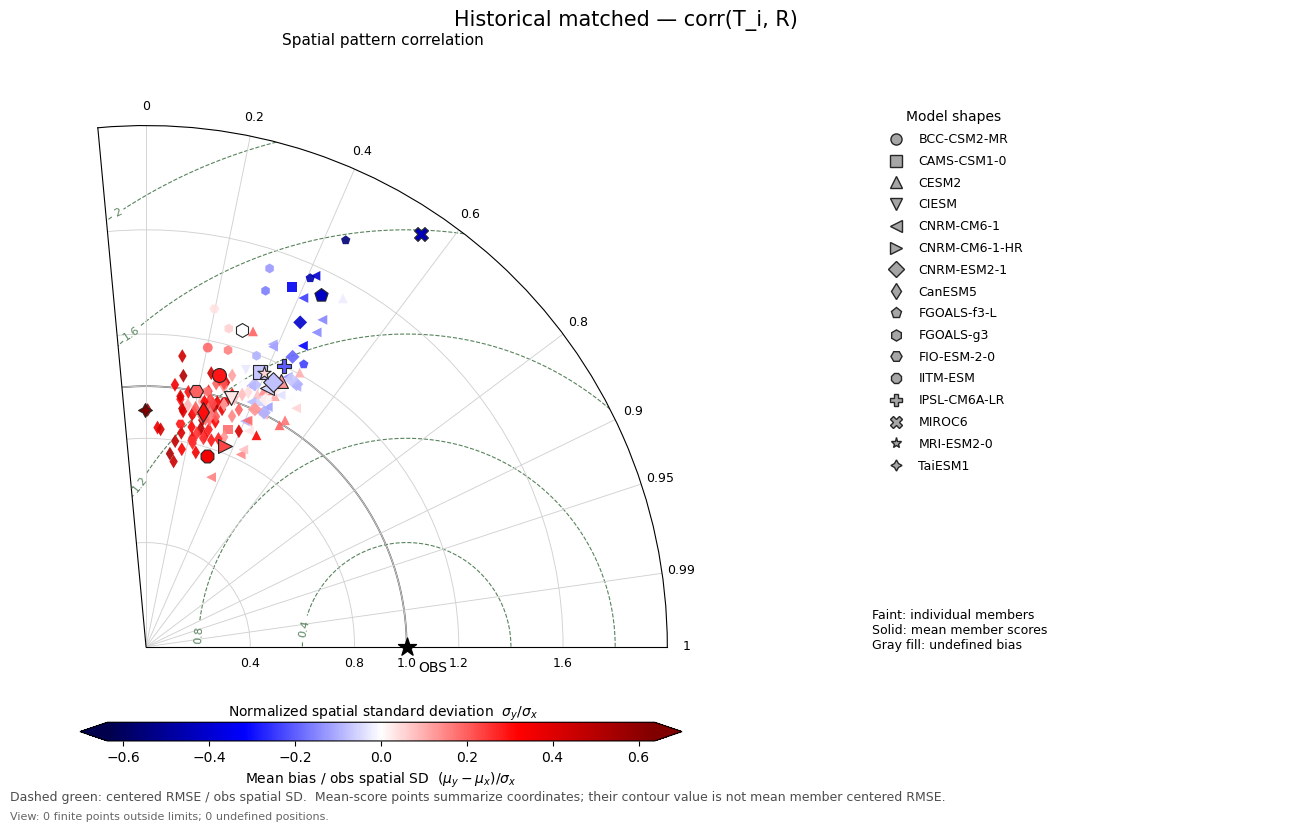

In [42]:
corr_setup = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "historical_matched", title="Historical matched — corr(T_i, R)",
    rmax=2, corr_min=None, zoom=True, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic"
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()


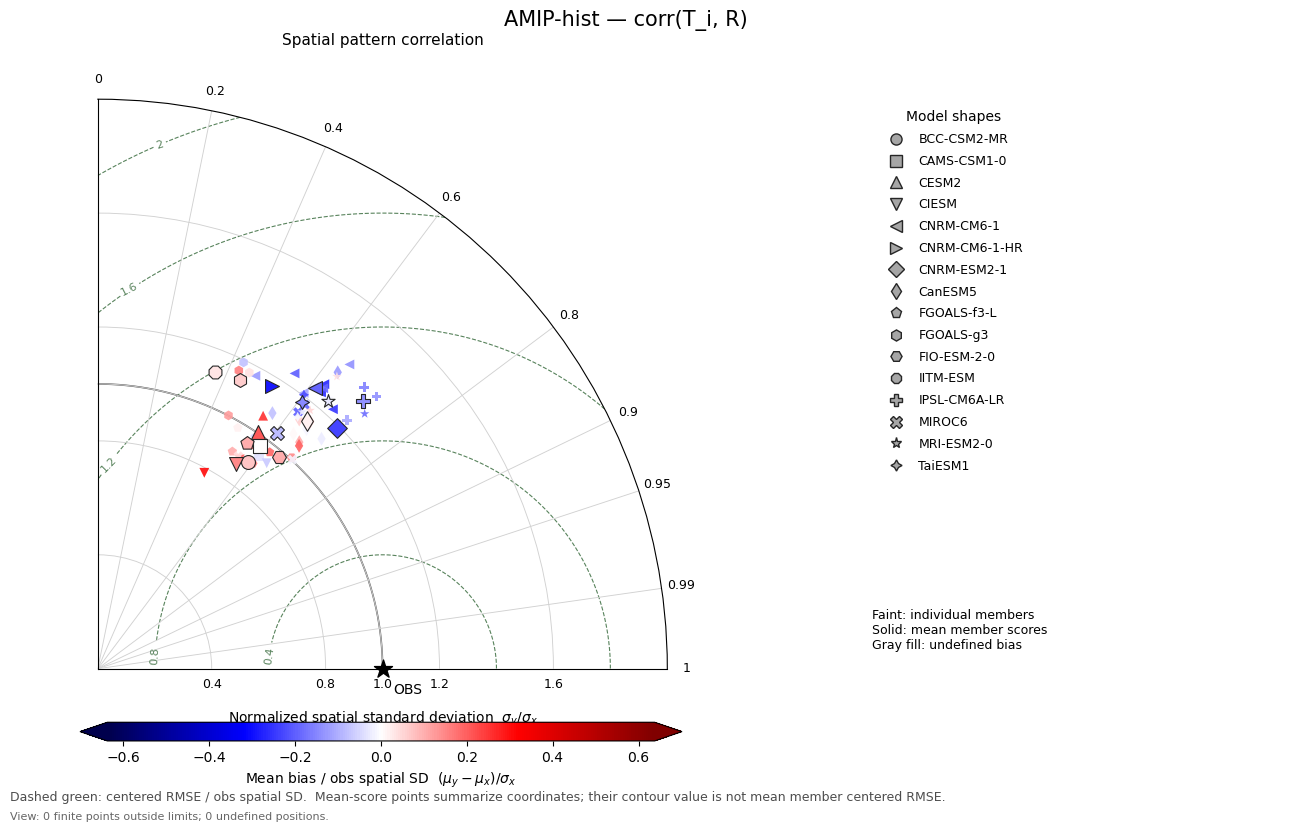

In [41]:
# %% Cell 3: prepare one diagnostic, then use the short plotting call
# This replaces the long setup block in your question. Keep different setups
# under different names so selecting one diagnostic does not overwrite another.
corr_setup = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "amip_hist", title="AMIP-hist — corr(T_i, R)",
    rmax=2, corr_min=None, zoom=False, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic"
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()




/scratch/leiff/MCA/amip_clean/project_functions/taylor_setup.py:255: UserWarning: Chosen extent hides 2 of 313 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


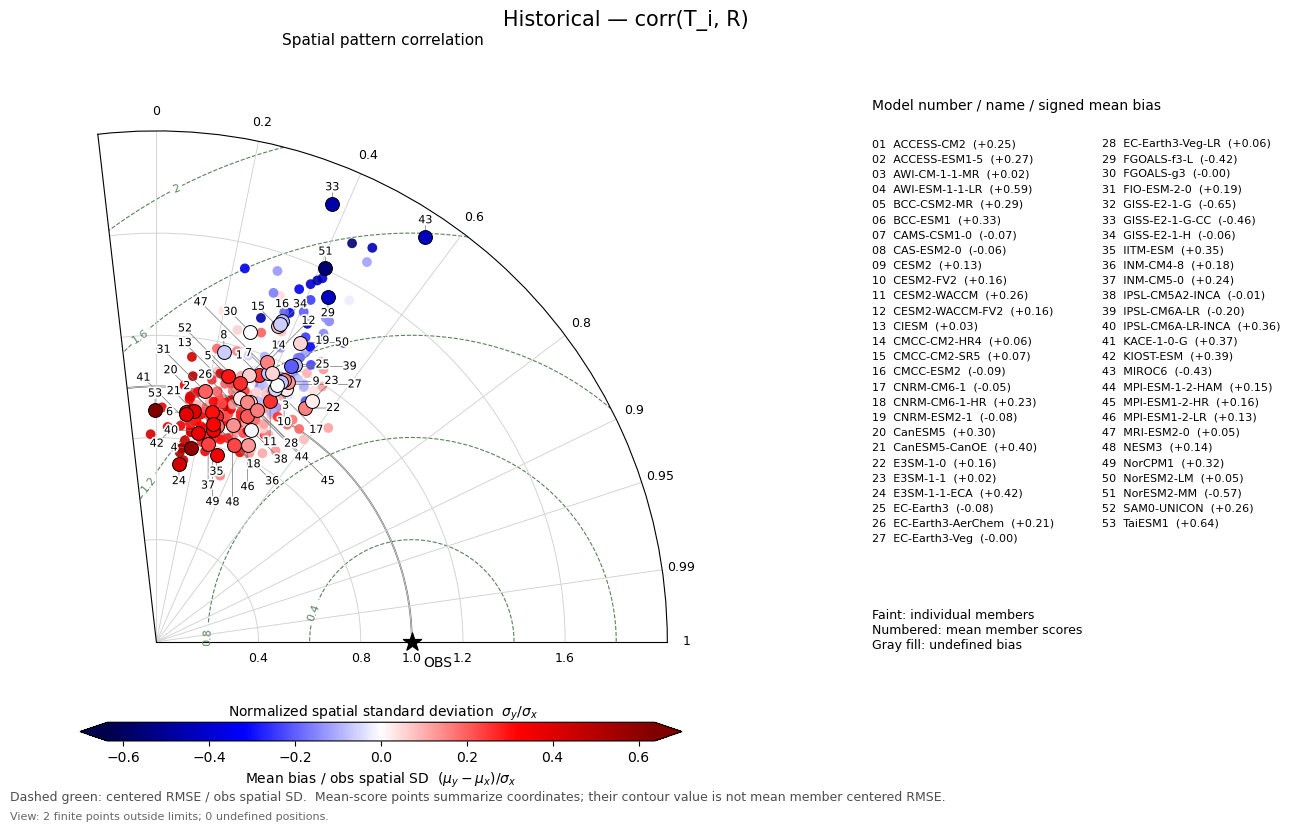

In [43]:
corr_setup = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "historical", title="Historical — corr(T_i, R)",
    rmax=2, corr_min=None, zoom=True, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic"
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()


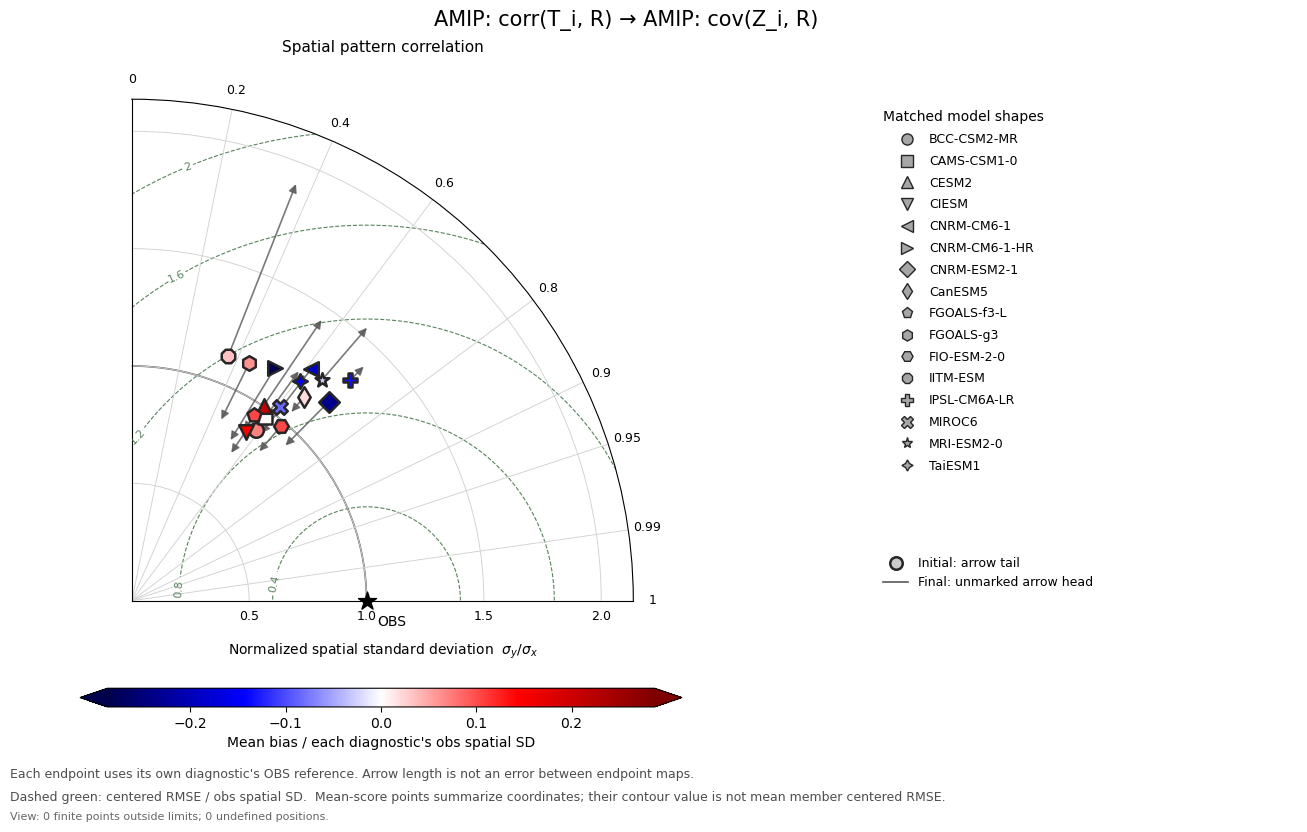

In [44]:
# %% Cell 4: corr(T_i, R) → cov(Z_i, R), within AMIP
# cov_Zi_R must already have been constructed PER MEMBER and scored against its
# observational equivalent. This wrapper cannot infer those nonlinear scores
# from the correlation scores alone. Reuse the marker mapping from corr_setup.
corr_setup = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)
cov_setup = setup_taylor("cov_Zi_R", overlap_member_scores, overlap_mean_member_scores,
                         model_markers=corr_setup["markers"])

fig_progression, ax_progression, progression_pairs = plot_taylor_transition(
    corr_setup["means"], cov_setup["means"], corr_setup["markers"],
    initial_experiment="amip_hist", final_experiment="amip_hist",
    initial_label="AMIP: corr(T_i, R)", final_label="AMIP: cov(Z_i, R)",
    show_final_markers=False, cmap="seismic", rmax=None, corr_min=None, zoom=False
)
# Change show_final_markers=True to add endpoints with their OWN bias colors.
# Set bias_vlim=max(corr_setup["bias_vlim"], cov_setup["bias_vlim"]) here and in
# both separate plots if all three figures should have an identical color scale.
plt.show()




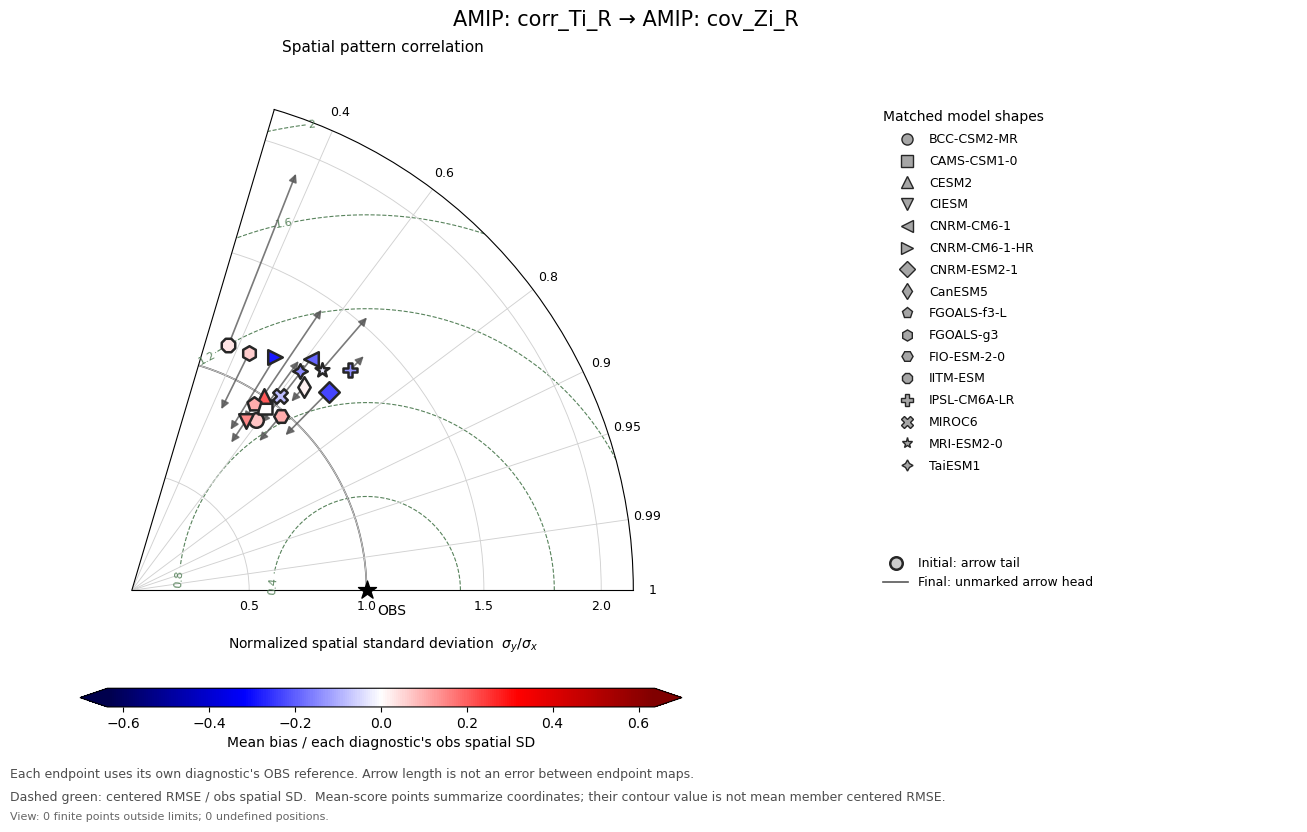

In [47]:
# %% Cell 5: manual endpoint selection — diagnostic AND experiment are independent
# Select the actual tables yourself; each must contain exactly one row per model.
# This example instead joins historical and AMIP for the SAME diagnostic. You
# can replace either table with one from another setup or choose an explicit
# common subset of models in BOTH tables before plotting. Row order may differ.
initial_setup   = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)
final_setup     = setup_taylor("cov_Zi_R", overlap_member_scores, overlap_mean_member_scores)

initial_taylor_means = initial_setup["means"].query("experiment == 'amip_hist'").copy()
final_taylor_means = final_setup["means"].query("experiment == 'amip_hist'").copy()

fig_manual, ax_manual, manual_pairs = plot_taylor_transition(
    initial_taylor_means, final_taylor_means, initial_setup["markers"],
    initial_label="AMIP: corr_Ti_R", final_label="AMIP: cov_Zi_R",
    show_final_markers=False, bias_vlim=initial_setup["bias_vlim"], cmap="seismic", zoom=True
)
plt.show()

Progression

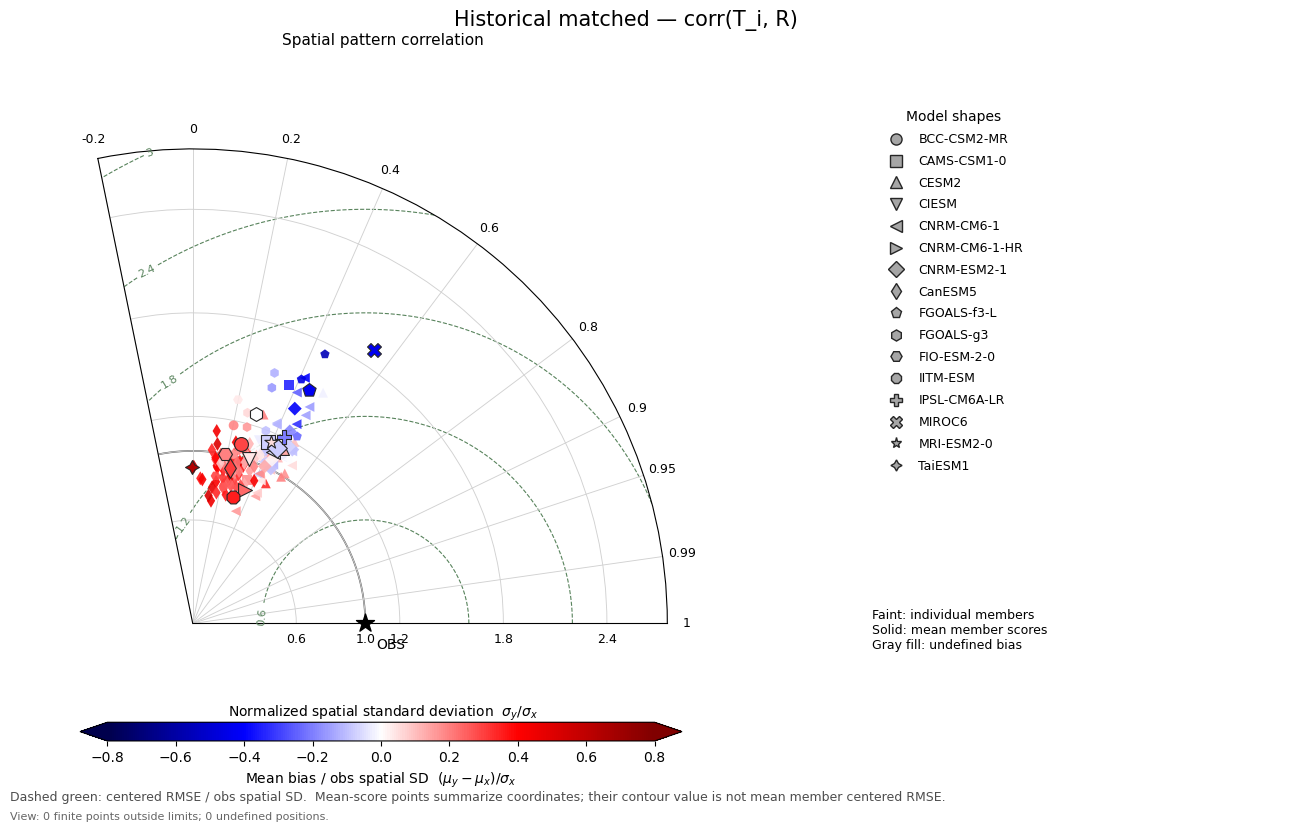

In [61]:
corr_setup = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "historical_matched", title="Historical matched — corr(T_i, R)",
    zoom=True, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic",
    rmax=2.75, bias_vlim=0.8, corr_min=-0.2, 
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()

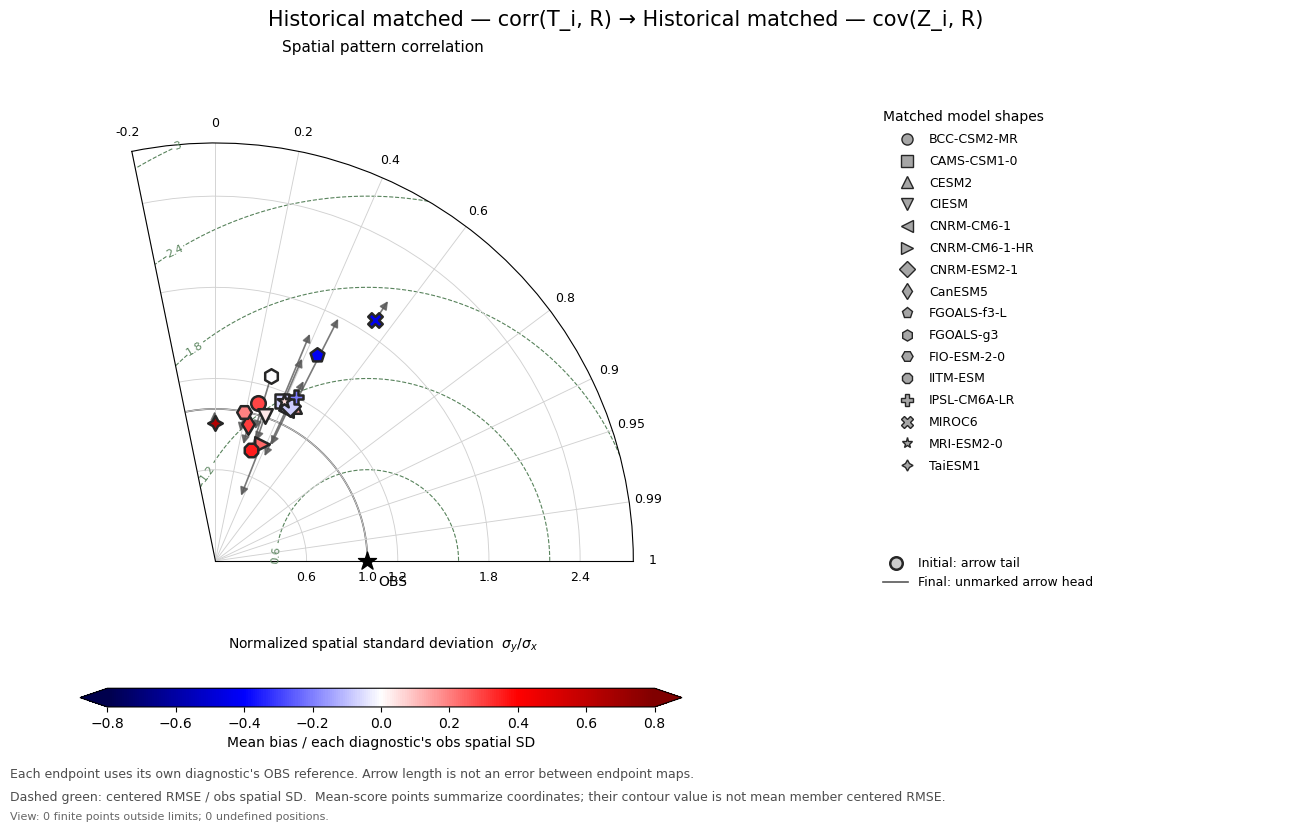

In [63]:
# %% Cell 5: manual endpoint selection — diagnostic AND experiment are independent
# Select the actual tables yourself; each must contain exactly one row per model.
# This example instead joins historical and AMIP for the SAME diagnostic. You
# can replace either table with one from another setup or choose an explicit
# common subset of models in BOTH tables before plotting. Row order may differ.
initial_setup   = setup_taylor("corr_Ti_R", overlap_member_scores, overlap_mean_member_scores)
final_setup     = setup_taylor("cov_Zi_R", overlap_member_scores, overlap_mean_member_scores)

initial_taylor_means = initial_setup["means"].query("experiment == 'historical_matched'").copy()
final_taylor_means = final_setup["means"].query("experiment == 'historical_matched'").copy()

fig_manual, ax_manual, manual_pairs = plot_taylor_transition(
    initial_taylor_means, final_taylor_means, initial_setup["markers"],
    initial_label="Historical matched — corr(T_i, R)", final_label="Historical matched — cov(Z_i, R)",
    show_final_markers=False, cmap="seismic", zoom=True, # bias_vlim=initial_setup["bias_vlim"],
    rmax=2.75, bias_vlim=0.8, corr_min=-0.2, 
)
plt.show()

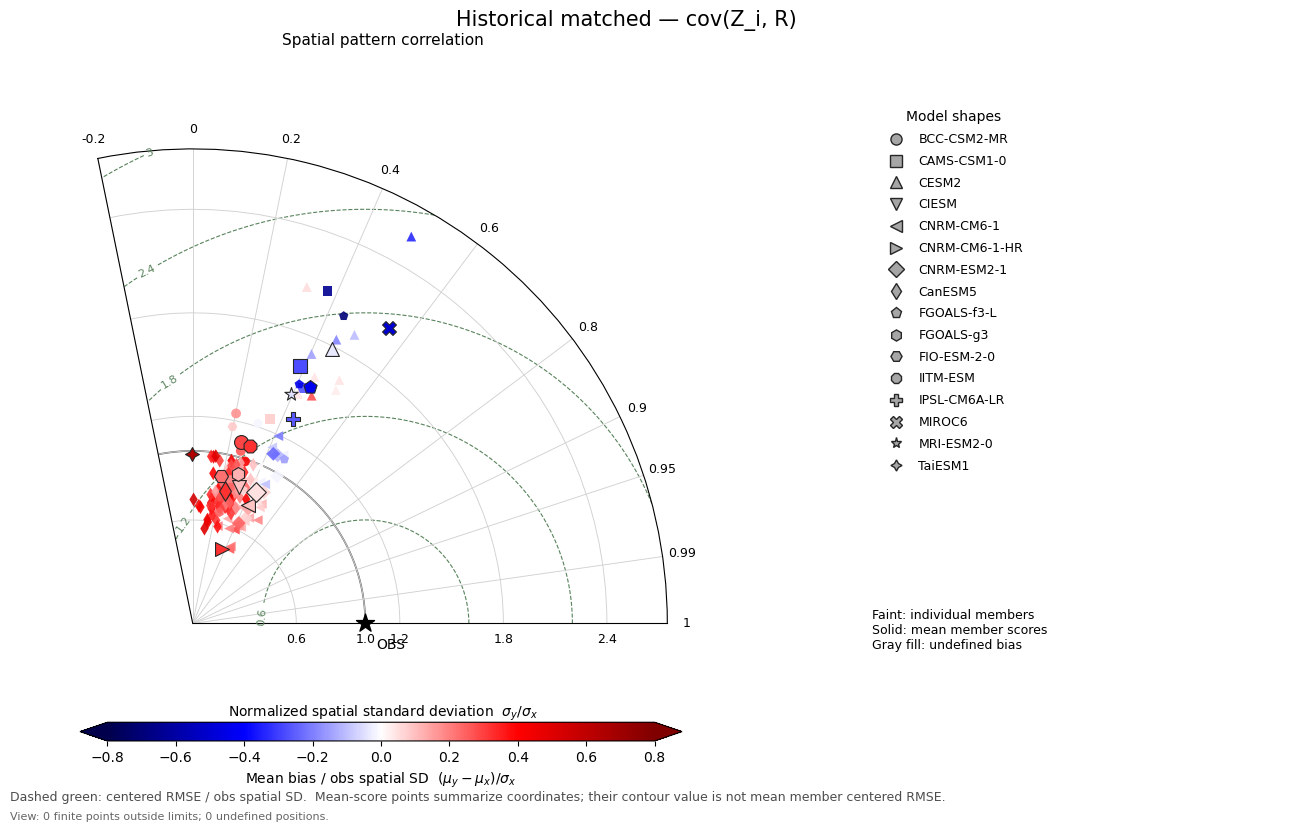

In [64]:
corr_setup = setup_taylor("cov_Zi_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "historical_matched", title="Historical matched — cov(Z_i, R)",
    zoom=True, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic",
    rmax=2.75, bias_vlim=0.8, corr_min=-0.2, 
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()

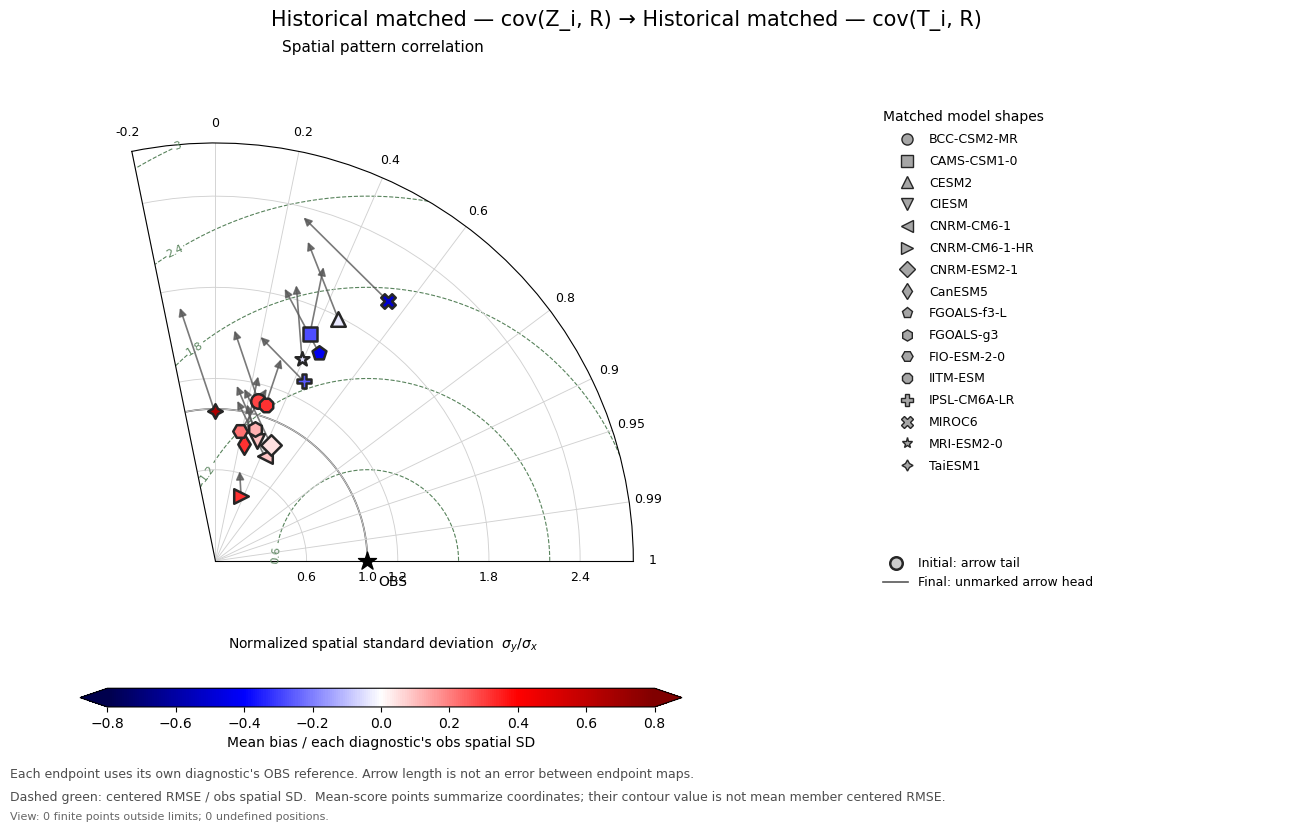

In [67]:
# %% Cell 5: manual endpoint selection — diagnostic AND experiment are independent
# Select the actual tables yourself; each must contain exactly one row per model.
# This example instead joins historical and AMIP for the SAME diagnostic. You
# can replace either table with one from another setup or choose an explicit
# common subset of models in BOTH tables before plotting. Row order may differ.
initial_setup   = setup_taylor("cov_Zi_R", overlap_member_scores, overlap_mean_member_scores)
final_setup     = setup_taylor("cov_Ti_R", overlap_member_scores, overlap_mean_member_scores)

initial_taylor_means = initial_setup["means"].query("experiment == 'historical_matched'").copy()
final_taylor_means = final_setup["means"].query("experiment == 'historical_matched'").copy()

fig_manual, ax_manual, manual_pairs = plot_taylor_transition(
    initial_taylor_means, final_taylor_means, initial_setup["markers"],
    initial_label="Historical matched — cov(Z_i, R)", final_label="Historical matched — cov(T_i, R)",
    show_final_markers=False, cmap="seismic", zoom=False, #  bias_vlim=initial_setup["bias_vlim"],
    rmax=2.75, bias_vlim=0.8, corr_min=-0.2, 
)
plt.show()

/scratch/leiff/MCA/amip_clean/project_functions/taylor_setup.py:255: UserWarning: Chosen extent hides 1 of 158 finite points; means still use all members.
  fig, ax, key_ax, visible = taylor_background(points, title, rmax=rmax, corr_min=corr_min,


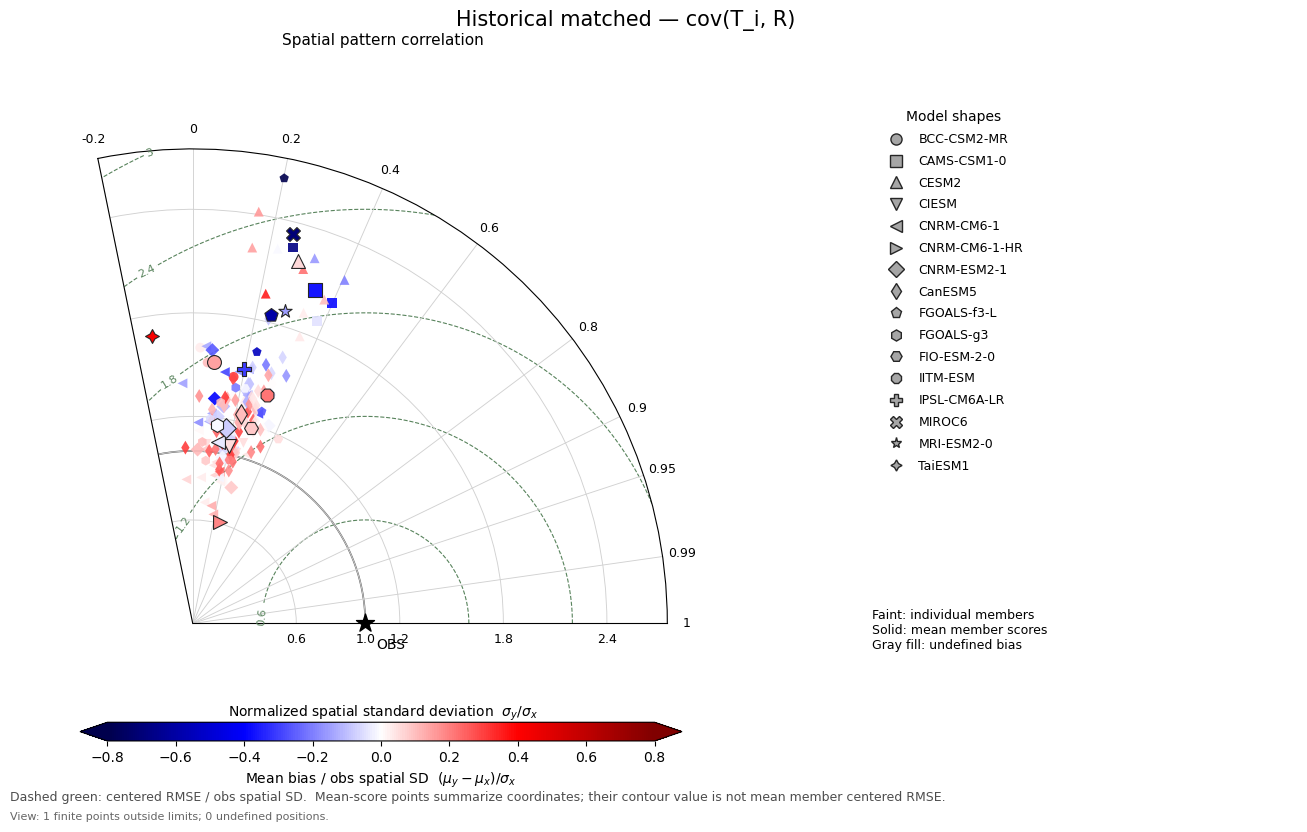

In [66]:
corr_setup = setup_taylor("cov_Ti_R", overlap_member_scores, overlap_mean_member_scores)

fig_corr, ax_corr, corr_key = plot_taylor_setup(
    corr_setup, "historical_matched", title="Historical matched — cov(T_i, R)",
    rmax=2.75, corr_min=-0.2, zoom=True, member_alpha=.9, member_size=50, mean_size=100, cmap="seismic",
    bias_vlim=0.8
)
# With the ORIGINAL plotting function instead, use exactly the same prepared values:
# fig_corr, ax_corr, corr_key = plot_taylor_experiment(
#     corr_setup["members"], corr_setup["means"], "amip_hist", corr_setup["markers"],
#     bias_label=corr_setup["bias_label"], bias_vlim=corr_setup["bias_vlim"], rmax=1.5)
plt.show()

In [ ]:
plot_model_maps()

In [37]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
lat_dim, lon_dim, ddof = "lat", "lon", 1

0.3


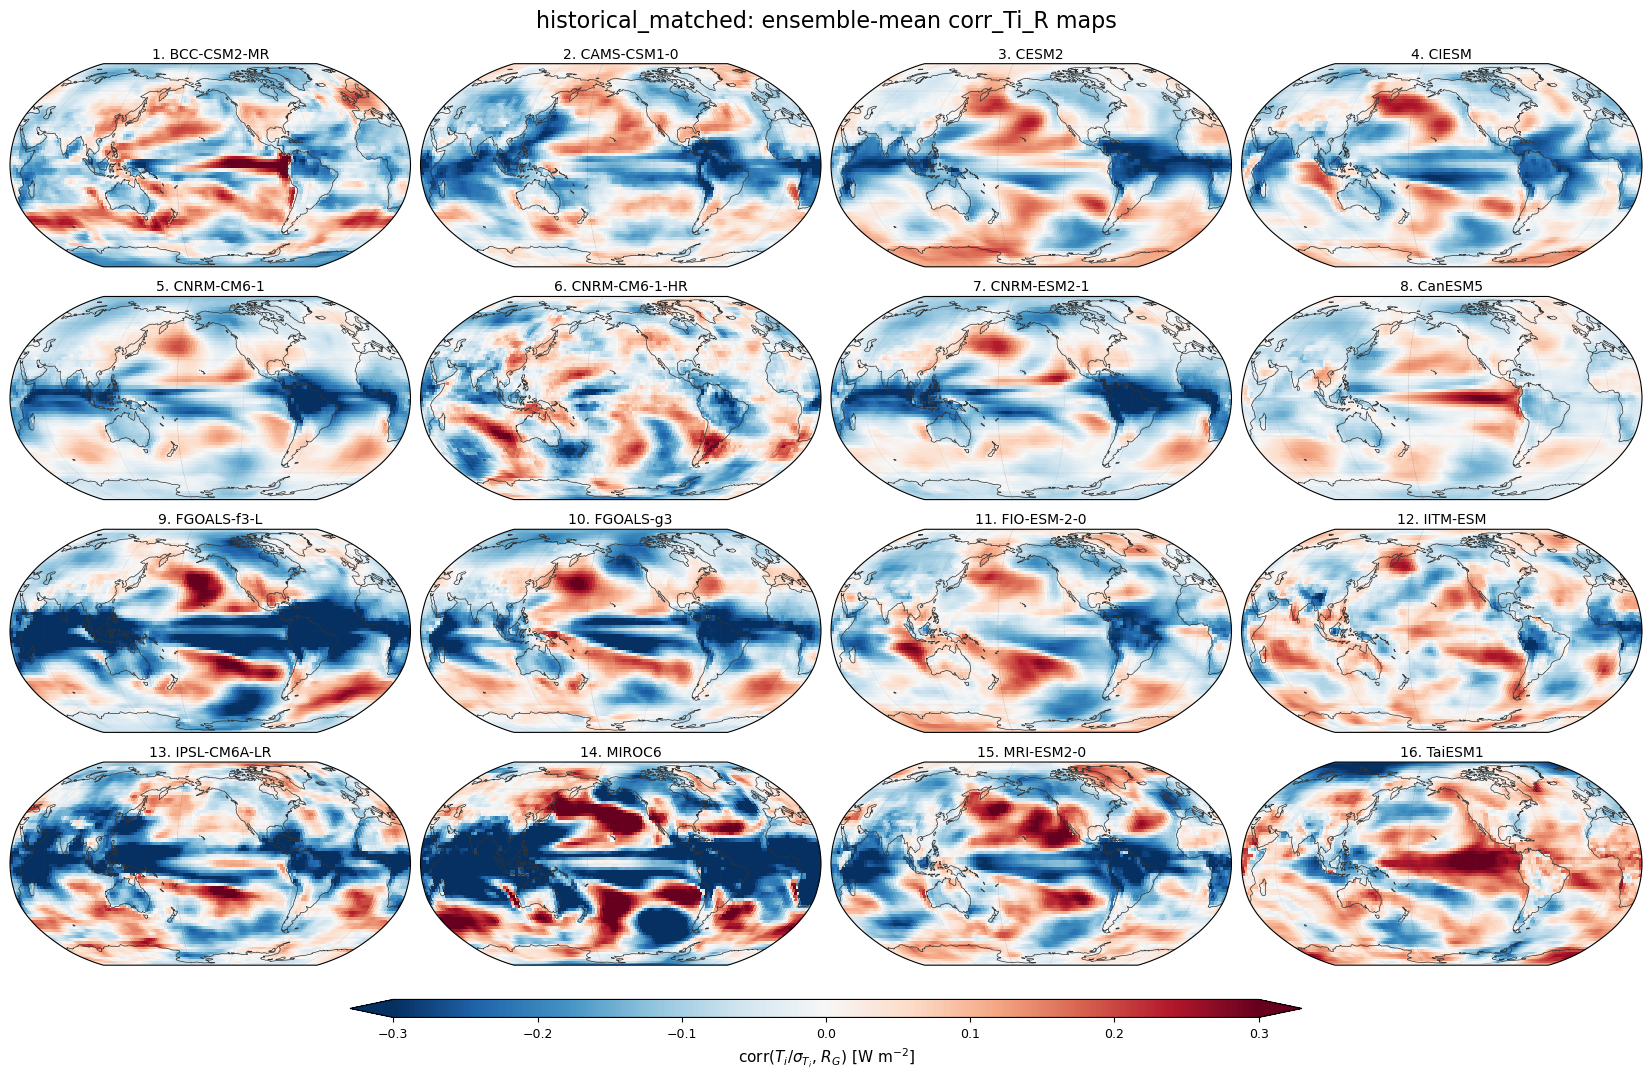

In [38]:
# Model names follow exactly the stacking order recorded during MMM preparation.
experiment, metric = "historical_matched", "corr_Ti_R"

fig, axes = plot_model_maps(
    overlap_model_means[experiment][metric], overlap_model_names[experiment], lat, lon,
    title=f"{experiment}: ensemble-mean {metric} maps", cmap="RdBu_r",vlim=0.3,
    colorbar_label=r"corr($T_i / \sigma_{T_i}$, $R_G$) [W m$^{-2}$]",
    # savepath = f"./data/maps_2000_2014_covImp/{experiment}/plots/{metric}_ensmeans_{experiment}_overlap",
    color_scale="linear", gamma=0.5, plot_method = "pcolormesh"
)

In [ ]:
# Historical symbols → AMIP arrowheads, with no AMIP endpoint symbols.
fig_taylor_origins, ax_taylor_origins, taylor_origin_pairs = plot_taylor_origin_arrows(
    taylor_means, taylor_markers,
    initial="historical_matched", final="amip_hist",
    title=f"Historical → AMIP — {taylor_metric}",
    bias_label=f"Historical: {taylor_bias_label}", bias_vlim=1,
    cmap="seismic", rmax=2.25, corr_min=-0.1, zoom=False,
    rms_levels=None, mean_size=100,
)
# fig_taylor_origins.savefig(f"/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/Taylor/taylor_historical_to_amip_arrows_{taylor_metric}.png", 
#                         dpi=300, bbox_inches="tight")
plt.show()

In [5]:
overlap_member_values

{'amip_hist': {'corr_Ti_Ri': {'BCC-CSM2-MR': array([[[-0.62641097, -0.63427498, -0.64000646, ..., -0.60537688,
            -0.6132859 , -0.61996025],
           [-0.64234654, -0.65439143, -0.66605926, ..., -0.5985261 ,
            -0.61436947, -0.62880919],
           [-0.59157604, -0.61190776, -0.63258436, ..., -0.50970063,
            -0.54119368, -0.56761855],
           ...,
           [-0.30848687, -0.27961015, -0.27521127, ..., -0.2030662 ,
            -0.2346697 , -0.24733592],
           [-0.22864888, -0.19759797, -0.21293156, ..., -0.15593956,
            -0.15390737, -0.20920051],
           [-0.25789537, -0.24595762, -0.24264768, ..., -0.24830514,
            -0.24865034, -0.26516824]]], shape=(1, 72, 144)),
   'CAMS-CSM1-0': array([[[-0.88328517, -0.88074933, -0.88461558, ..., -0.88126893,
            -0.88455424, -0.8892592 ],
           [-0.86509692, -0.86273983, -0.86252579, ..., -0.85912449,
            -0.85479725, -0.85842231],
           [-0.86551801, -0.86520464, -0

In [6]:
# %% 1. Reusable time-series plot using the loaded overlap_* dictionaries
import numpy as np
import matplotlib.pyplot as plt

def plot_overlap_timeseries(experiment, quantity="R_detrended", *, models=None, colors=None,
                            bands=((0, 100),), band_alphas=(0.10,), model_lw=1.3, MMM_lw=3.2,
                            title=None, ylabel=None, figsize=(13, 5), ax=None):
    """Colored mean-member series, pointwise ensemble-spread bands, and a black MMM.

    Uses overlap_member_values, overlap_model_means, overlap_MMM,
    overlap_model_names, and overlap_coordinates already loaded in the notebook.
    quantity: T_detrended, R_detrended, T_trend_in, or R_trend_in.
    bands: percentile pairs, widest first; band_alphas: corresponding opacities.
    models=None plots the whole experiment; a subset gets its own equal-model MMM.
    colors can be a {model: matplotlib_color} dictionary. Returns fig, ax.
    """
    # Resolve the model axis by NAME, not by assuming the groups share array order.
    # The saved model means are means of members' SERIES, shaped (model, time).
    names = list(overlap_model_names[experiment])
    selected = names if models is None else list(models)
    if not selected or len(selected) != len(set(selected)) or any(m not in names for m in selected):
        raise ValueError("models must be a nonempty, unique subset of this experiment's model names.")
    time = np.asarray(overlap_coordinates["time"])
    all_means = np.asarray(overlap_model_means[experiment][quantity], dtype=float)
    if time.ndim != 1 or all_means.shape != (len(names), len(time)):
        raise ValueError("Choose a time-series quantity: expected model means with shape (model, time).")
    means = all_means[[names.index(model) for model in selected]]

    # Percentile bands describe member spread at EACH month. They are not confidence
    # intervals, and their boundaries need not follow a single member through time.
    # With only a few members, intermediate percentiles are interpolated summaries.
    bands, band_alphas = list(bands), list(band_alphas)
    if len(bands) != len(band_alphas):
        raise ValueError("Supply one opacity in band_alphas for each percentile pair in bands.")
    for (low, high), alpha in zip(bands, band_alphas):
        if not (0 <= low < high <= 100 and 0 <= alpha <= 1):
            raise ValueError("Percentiles must satisfy 0 <= low < high <= 100, and opacity must be 0–1.")

    # Create the color lookup from ALL archived model names, so the same model keeps
    # its color across historical, matched historical, AMIP, and plotted subsets.
    # Supply your own colors dictionary if you already have preferred model colors.
    if colors is None:
        all_names = list(dict.fromkeys(m for group in overlap_model_names.values() for m in group))
        palette = plt.get_cmap("tab20" if len(all_names) <= 20 else "turbo")
        colors = dict(zip(all_names, palette(np.linspace(0., 1., len(all_names)))))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    # Draw the widest band first, then narrower/darker bands, then each model mean.
    # At least TWO finite members are needed for shading at a month. In particular,
    # a single-member model has a line but no apparent zero-width uncertainty band.
    for i, model in enumerate(selected):
        members = np.asarray(overlap_member_values[experiment][quantity][model], dtype=float)
        if members.ndim != 2 or members.shape[1] != len(time) or members.shape[0] == 0:
            raise ValueError(f"{model}: expected member series shaped (member, time).")
        members = np.where(np.isfinite(members), members, np.nan)
        shade = np.isfinite(members).sum(axis=0) >= 2
        for (low, high), alpha in zip(bands, band_alphas):
            lower, upper = np.full(len(time), np.nan), np.full(len(time), np.nan)
            if shade.any():
                lower[shade], upper[shade] = np.nanpercentile(members[:, shade], [low, high], axis=0)
            ax.fill_between(time, lower, upper, where=shade, color=colors[model],
                            alpha=alpha, linewidth=0, zorder=1)
        ax.plot(time, means[i], color=colors[model], lw=model_lw, label=model, zorder=3)

    # Use the saved equal-model MMM for the full experiment. If explicitly selecting
    # models, average just their saved model means; do NOT pool ensemble members.
    # This line is a mean time series, not a summary of members' temporal SDs.
    if models is None:
        MMM = np.asarray(overlap_MMM[experiment][quantity], dtype=float)
    else:
        finite = np.isfinite(means)
        count = finite.sum(axis=0)
        total = np.where(finite, means, 0.).sum(axis=0)
        MMM = np.divide(total, count, out=np.full(len(time), np.nan), where=count > 0)
    if MMM.shape != (len(time),):
        raise ValueError("The MMM must have shape (time,).")
    ax.plot(time, MMM, color="black", lw=MMM_lw, label="MMM (equal model weight)", zorder=5)

    # Put labels/legend outside the data where possible. No smoothing, detrending,
    # rescaling, or anomaly calculation is performed by this plotting function.
    ax.axhline(0., color="0.6", lw=0.7, ls=":", zorder=0)
    ax.set(xlabel="Year", ylabel=quantity if ylabel is None else ylabel,
           title=f"{experiment}: {quantity}" if title is None else title)
    ax.grid(alpha=0.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,
              fontsize=8, ncol=1 if len(selected) <= 12 else 2)
    return fig, ax




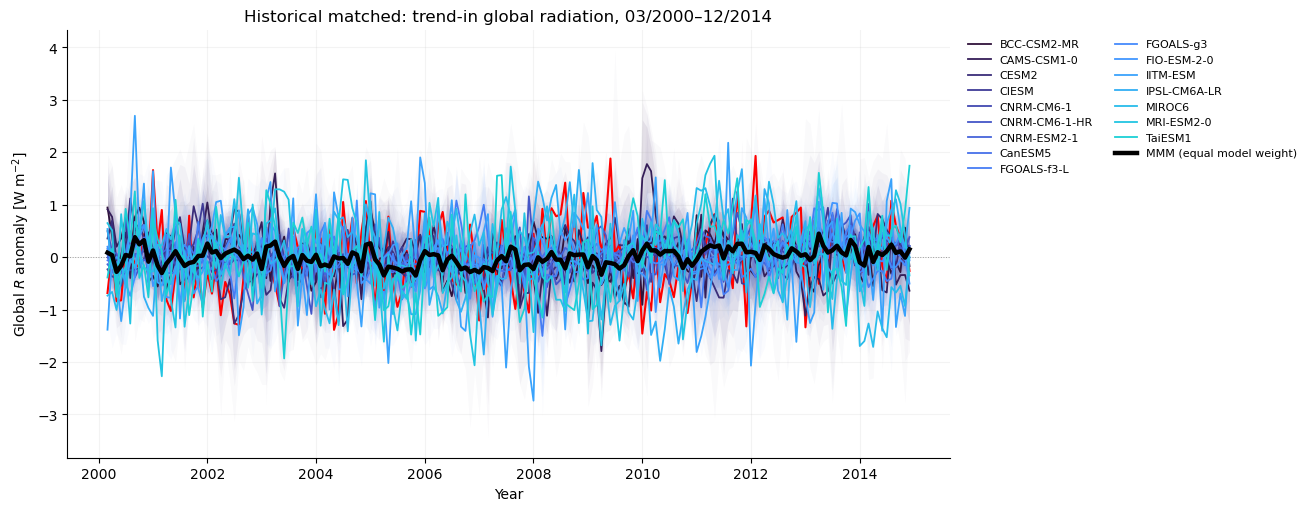

In [10]:
# %% 2. Quick template: change the experiment, quantity, and band opacity here
# Other experiment choices: "amip_hist", "historical".
# Other series: "T_detrended", "T_trend_in", "R_trend_in". Update the label too.
# The example retains the input radiation units (expected W m^-2 in your files).
fig, ax = plot_overlap_timeseries(
    experiment="historical_matched", quantity="R_trend_in",
    bands=((0, 100), (10, 90), (25, 75)), band_alphas=(0.025, 0.04, 0.08),
    ylabel=r"Global $R$ anomaly [W m$^{-2}$]",
    title="Historical matched: trend-in global radiation, 03/2000–12/2014",
)
plt.plot(overlap_coordinates['time'],overlap_observations['R_trend_in'],'r')
plt.show()

# For one simple full-range band instead, use bands=((0, 100),), band_alphas=(0.10,).
# Opacities range from 0 (invisible) to 1 (opaque); overlapping bands build opacity.
# For lines only, use bands=(), band_alphas=().
# For selected models, add models=["model-name-1", "model-name-2"] to the call.
# To save after inspection: fig.savefig("./overlap_timeseries.png", dpi=200, bbox_inches="tight")

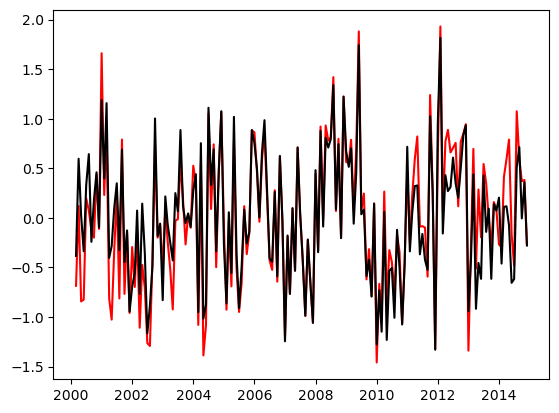

In [12]:
plt.plot(overlap_coordinates['time'],overlap_observations['R_trend_in'],'r')
plt.plot(overlap_coordinates['time'],overlap_observations['R_detrended'],'k')

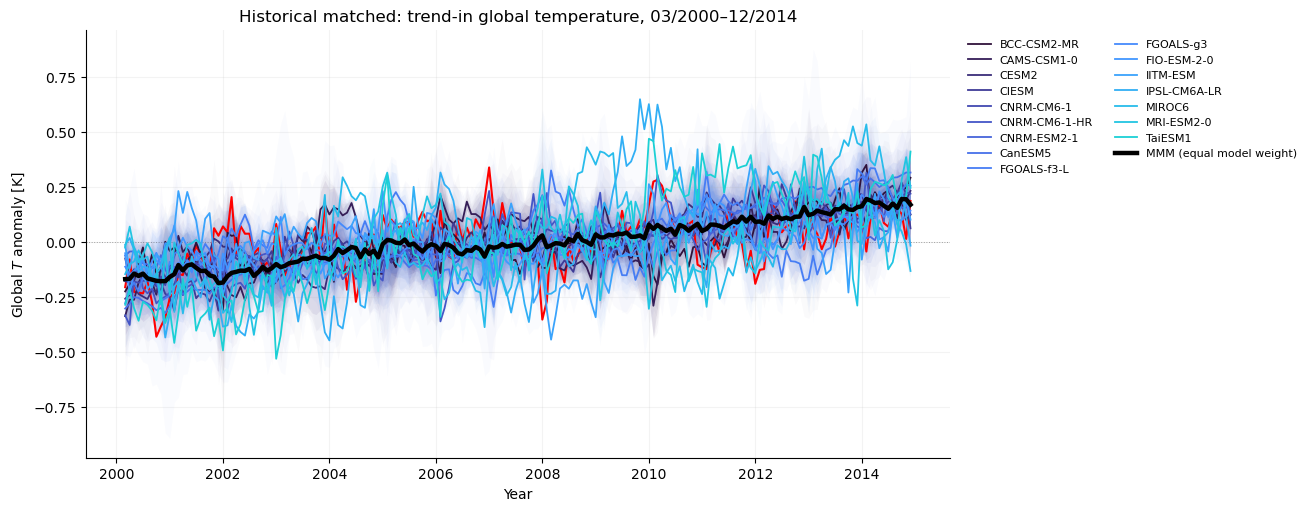

In [21]:
fig, ax = plot_overlap_timeseries(
    experiment="historical_matched", quantity="T_trend_in",
    bands=((0, 100), (10, 90), (25, 75)), band_alphas=(0.025, 0.04, 0.08),
    ylabel=r"Global $T$ anomaly [K]",
    title="Historical matched: trend-in global temperature, 03/2000–12/2014",
)
plt.plot(overlap_coordinates['time'],overlap_observations['T_trend_in'],'r')
plt.show()

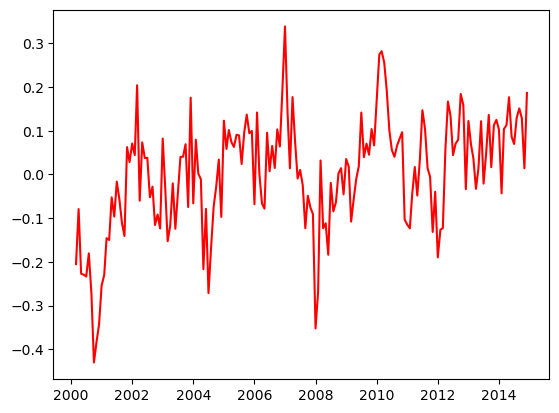

In [17]:
plt.plot(overlap_coordinates['time'],overlap_observations['T_trend_in'],'r')
# plt.plot(overlap_coordinates['time'],overlap_observations['T_detrended'],'k')

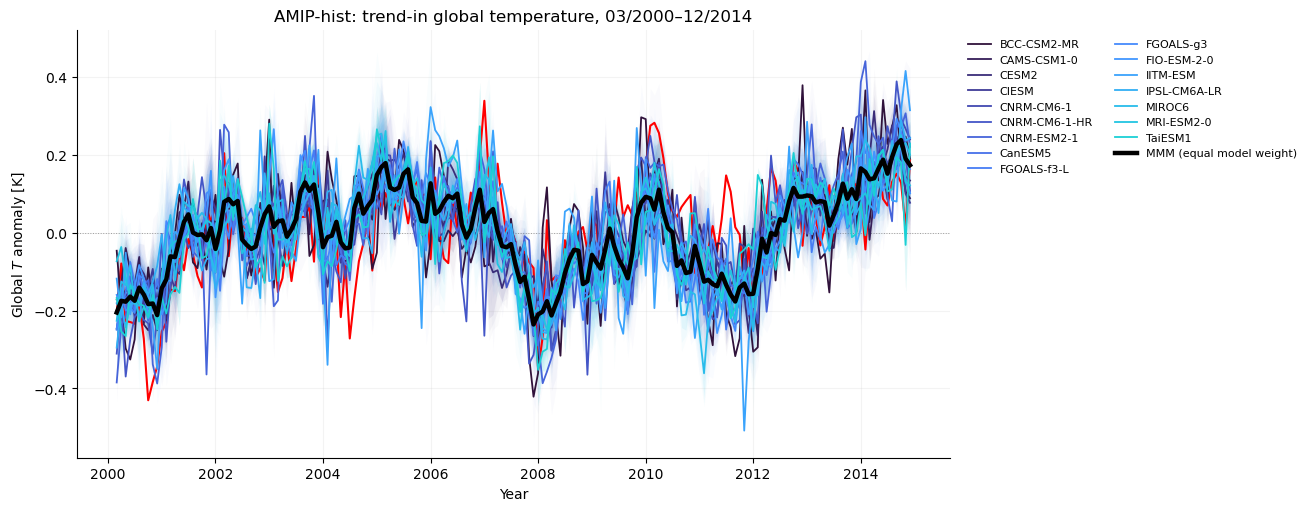

In [20]:
fig, ax = plot_overlap_timeseries(
    experiment="amip_hist", quantity="T_trend_in",
    bands=((0, 100), (10, 90), (25, 75)), band_alphas=(0.025, 0.04, 0.08),
    ylabel=r"Global $T$ anomaly [K]",
    title="AMIP-hist: trend-in global temperature, 03/2000–12/2014",
)
plt.plot(overlap_coordinates['time'],overlap_observations['T_trend_in'],'r')

plt.show()